## Let's Code Our First MoE! 💻

Alright, enough theory let's actually build a “classroom” of experts in Python!

In this example, each expert is like a student who's really good at a particular subject (math, science, literature, art, or history). When you ask a question, the MoE (our “classroom manager”) decides which experts are the best match to answer.
The **router** checks which experts are most relevant, picks the top 2, and then combines their answers to give you a final result.

You'll see:

* How the router “scores” each expert based on your question
* How only the best-matching experts are picked (not everyone has to answer!)
* How their answers are combined, with more weight given to the better match

Ready? Try running the code and see which students answer your questions!


In [ ]:
import random

class SimpleExpert:
    """One expert student in our class"""
    def __init__(self, name, specialty):
        self.name = name
        self.specialty = specialty

    def answer(self, question):
        # Each expert answers in their own style
        return f"{self.name} says: Here's my {self.specialty} take on '{question}'"

class SimpleMoE:
    """Our classroom of experts"""
    def __init__(self):
        # Create our expert students
        self.experts = [
            SimpleExpert("Rimi", "science"),
            SimpleExpert("Hasan", "literature"),
            SimpleExpert("Hamim", "math"),
            SimpleExpert("Richi", "history"),
            SimpleExpert("Emma", "art")
        ]

    def router(self, question):
        """Decide which experts should answer"""
        scores = []

        # Give each expert a score based on the question
        for expert in self.experts:
            if expert.specialty in question.lower():
                score = 0.9  # High score if specialty matches!
            else:
                score = random.uniform(0.1, 0.3)  # Low random score
            scores.append(score)

        return scores

    def answer_question(self, question):
        """Get answer from the best 2 experts"""
        # Get scores from router
        scores = self.router(question)

        # Find top 2 experts
        expert_scores = list(zip(self.experts, scores))
        expert_scores.sort(key=lambda x: x[1], reverse=True)
        top_experts = expert_scores[:2]

        print(f"\n📚 Question: '{question}'")
        print(f"🎯 Choosing experts...")

        # Show the selection process
        for expert, score in expert_scores:
            status = "✅ SELECTED" if (expert, score) in top_experts else "❌"
            print(f"   {expert.name} ({expert.specialty}): {score:.2f} {status}")

        # Get answers from top experts
        print(f"\n💭 Expert answers:")
        total_score = sum(score for _, score in top_experts)
        final_answer = ""

        for expert, score in top_experts:
            weight = score / total_score
            answer = expert.answer(question)
            print(f"   {answer} (weight: {weight:.2f})")
            final_answer += f"{answer} "

        return final_answer

# Let's try it!
moe = SimpleMoE()

# Ask different questions
questions = [
    "Tell me about science experiments",
    "What's the best math formula?",
    "Explain art techniques",
    "Write a literature story"
]

for q in questions:
    moe.answer_question(q)
    print("-" * 50)


📚 Question: 'Tell me about science experiments'
🎯 Choosing experts...
   Rimi (science): 0.90 ✅ SELECTED
   Emma (art): 0.27 ✅ SELECTED
   Hasan (literature): 0.26 ❌
   Hamim (math): 0.26 ❌
   Richi (history): 0.13 ❌

💭 Expert answers:
   Rimi says: Here's my science take on 'Tell me about science experiments' (weight: 0.77)
   Emma says: Here's my art take on 'Tell me about science experiments' (weight: 0.23)
--------------------------------------------------

📚 Question: 'What's the best math formula?'
🎯 Choosing experts...
   Hamim (math): 0.90 ✅ SELECTED
   Richi (history): 0.21 ✅ SELECTED
   Emma (art): 0.20 ❌
   Rimi (science): 0.13 ❌
   Hasan (literature): 0.11 ❌

💭 Expert answers:
   Hamim says: Here's my math take on 'What's the best math formula?' (weight: 0.81)
   Richi says: Here's my history take on 'What's the best math formula?' (weight: 0.19)
--------------------------------------------------

📚 Question: 'Explain art techniques'
🎯 Choosing experts...
   Emma (art): 0.

## Making It Real: MoE with Neural Networks 🤖

Our first classroom MoE used simple “if you like science, answer the science question” logic.
But real AI doesn't just check for keywords it uses **tiny neural networks** as experts!

Now, each expert is a *mini brain* (a real neural network) that learns its own way of answering.
The “router” is also a neural network, which looks at the question (actually, a vector of numbers) and decides which experts to activate, and *how much* each expert should contribute to the final answer.

What happens here:

* Each expert is a neural network with its own (random) knowledge.
* The router neural network scores all the experts for each input.
* Only the **top 2 experts** are picked, and their outputs are combined (using probabilities, like voting weights).
* You'll see which experts were chosen, how much they contributed, and the final combined answer!

This brings us closer to how large language models like GPT really use Mixture of Experts at scale.

Let's build a tiny Neural MoE and see it in action:


In [ ]:
import numpy as np

class NeuralExpert:
    """A tiny neural network expert"""
    def __init__(self, name, input_size=10, hidden_size=5):
        self.name = name
        # Random weights (like random knowledge!)
        self.weights1 = np.random.randn(input_size, hidden_size) * 0.1
        self.weights2 = np.random.randn(hidden_size, 1) * 0.1

    def forward(self, x):
        """Process input through the neural network"""
        # Simple neural network: input -> hidden -> output
        hidden = np.maximum(0, np.dot(x, self.weights1))  # ReLU activation
        output = np.dot(hidden, self.weights2)
        return output[0]

class NeuralMoE:
    """MoE with actual neural networks"""
    def __init__(self, num_experts=4, input_size=10):
        self.num_experts = num_experts
        self.input_size = input_size

        # Create expert networks
        self.experts = [
            NeuralExpert(f"Expert_{i}", input_size)
            for i in range(num_experts)
        ]

        # Router network (decides which experts to use)
        self.router_weights = np.random.randn(input_size, num_experts) * 0.1

    def forward(self, x):
        """Process input through MoE"""
        # Step 1: Router scores each expert
        router_scores = np.dot(x, self.router_weights)

        # Step 2: Pick top 2 experts (using softmax for probabilities)
        exp_scores = np.exp(router_scores - np.max(router_scores))
        probabilities = exp_scores / np.sum(exp_scores)

        top_2_indices = np.argsort(probabilities)[-2:]

        # Step 3: Get outputs from top experts
        final_output = 0
        print(f"\n🧠 Expert Selection:")

        for i in range(self.num_experts):
            if i in top_2_indices:
                expert_output = self.experts[i].forward(x)
                weight = probabilities[i]
                final_output += weight * expert_output
                print(f"   Expert_{i}: {probabilities[i]:.3f} ✅ (output: {expert_output:.3f})")
            else:
                print(f"   Expert_{i}: {probabilities[i]:.3f} ❌")

        return final_output

# Demo time!
moe = NeuralMoE(num_experts=4, input_size=10)

# Create some sample inputs
print("🎮 Testing our Neural MoE:\n")

for i in range(3):
    # Random input (like a random question)
    test_input = np.random.randn(10)
    output = moe.forward(test_input)
    print(f"\n📊 Final output: {output:.3f}")
    print("-" * 40)

🎮 Testing our Neural MoE:


🧠 Expert Selection:
   Expert_0: 0.223 ❌
   Expert_1: 0.317 ✅ (output: 0.120)
   Expert_2: 0.219 ❌
   Expert_3: 0.242 ✅ (output: 0.027)

📊 Final output: 0.045
----------------------------------------

🧠 Expert Selection:
   Expert_0: 0.277 ✅ (output: -0.248)
   Expert_1: 0.138 ❌
   Expert_2: 0.271 ❌
   Expert_3: 0.315 ✅ (output: -0.031)

📊 Final output: -0.079
----------------------------------------

🧠 Expert Selection:
   Expert_0: 0.167 ❌
   Expert_1: 0.389 ✅ (output: 0.019)
   Expert_2: 0.210 ❌
   Expert_3: 0.234 ✅ (output: -0.019)

📊 Final output: 0.003
----------------------------------------


## Why MoE Is So Efficient: Sparsity Saves the Day! ✨

One of the coolest tricks in Mixture of Experts is **sparsity** which is just a fancy way to say *not everyone works at once*.

In a regular neural network, **every expert** has to do the work for every question, even if their specialty isn't needed. That's a lot of wasted energy!
But in MoE, only the **top experts** for each question get called up to the stage. This means the AI can be much larger and smarter without slowing down or using tons of extra compute.

Let's see just how much work MoE saves compared to a traditional model:


In [ ]:
def demonstrate_sparsity():
    """Show how MoE saves computation"""

    # Traditional approach: Everyone works
    traditional_work = 8 * 100  # 8 experts × 100 units of work each
    print(f"🏃 Traditional NN: {traditional_work} units of work")

    # MoE approach: Only top 2 work
    moe_work = 2 * 100  # Only 2 experts × 100 units of work
    print(f"🚀 MoE: {moe_work} units of work")

    savings = (traditional_work - moe_work) / traditional_work * 100
    print(f"💰 Savings: {savings:.0f}% less work!")

    # Visual representation
    print("\n📊 Work Distribution:")
    print("Traditional: ████████ (all 8 experts)")
    print("MoE:         ██       (only 2 experts)")

demonstrate_sparsity()

🏃 Traditional NN: 800 units of work
🚀 MoE: 200 units of work
💰 Savings: 75% less work!

📊 Work Distribution:
Traditional: ████████ (all 8 experts)
MoE:         ██       (only 2 experts)


## Build Your Own Mixture of Experts! 👷‍♂️

Ready to get hands-on?
Let's build a simple MoE system step by step—no magic, just basic Python and some creative thinking.

In this mini-project, you'll:

* Create your own set of “experts,” each with a unique specialty (math, science, art, music)
* Build a “router” that picks the best experts for each question or task
* See how the selected experts work together to answer different types of prompts

It's like running your own classroom and deciding who gets to answer each question!

Let's walk through the recipe for your very own MoE:


In [ ]:
class DIYMoE:
    """Build your own MoE step by step!"""

    def __init__(self):
        print("🏗️ Building your MoE...\n")

        # Step 1: Create experts
        print("Step 1: Creating experts 👥")
        self.experts = self.create_experts()

        # Step 2: Create router
        print("\nStep 2: Creating router 🎯")
        self.router = self.create_router()

        # Step 3: Ready to go!
        print("\n✅ Your MoE is ready!")

    def create_experts(self):
        """Make different expert types"""
        experts = {
            "math": lambda x: f"Math says: {x} × 2 = {x*2}",
            "science": lambda x: f"Science says: {x} atoms make a molecule",
            "art": lambda x: f"Art says: {x} is a beautiful number",
            "music": lambda x: f"Music says: {x} notes make a chord"
        }
        for name in experts:
            print(f"   ✓ Created {name} expert")
        return experts

    def create_router(self):
        """Decide which experts to use based on input type"""
        def router(question_type):
            if "calculate" in question_type:
                return ["math", "science"]
            elif "create" in question_type:
                return ["art", "music"]
            else:
                # Random selection
                import random
                return random.sample(list(self.experts.keys()), 2)

        print("   ✓ Router ready to select experts")
        return router

    def process(self, question_type, value):
        """Use the MoE to process input"""
        print(f"\n🎤 Processing: '{question_type}' with value {value}")

        # Router selects experts
        selected = self.router(question_type)
        print(f"🎯 Router selected: {selected}")

        # Get answers from selected experts
        print("💭 Expert responses:")
        for expert_name in selected:
            response = self.experts[expert_name](value)
            print(f"   - {response}")

# Try it out!
my_moe = DIYMoE()
my_moe.process("calculate something", 5)
my_moe.process("create something", 3)

🏗️ Building your MoE...

Step 1: Creating experts 👥
   ✓ Created math expert
   ✓ Created science expert
   ✓ Created art expert
   ✓ Created music expert

Step 2: Creating router 🎯
   ✓ Router ready to select experts

✅ Your MoE is ready!

🎤 Processing: 'calculate something' with value 5
🎯 Router selected: ['math', 'science']
💭 Expert responses:
   - Math says: 5 × 2 = 10
   - Science says: 5 atoms make a molecule

🎤 Processing: 'create something' with value 3
🎯 Router selected: ['art', 'music']
💭 Expert responses:
   - Art says: 3 is a beautiful number
   - Music says: 3 notes make a chord


## Which Experts Get Picked Most? 🏆

Ever wondered which experts in your MoE system get called on the most?
Let's run a quick “popularity contest” to see which specialists are the router's favorites!

This experiment will:

* Simulate asking lots of questions
* Randomly select 2 experts each time (like picking a team for a game)
* Count how many times each expert gets picked

Check out the results below to see if some experts are real crowd-pleasers!

In [ ]:
def expert_popularity_contest(num_questions=100):
    """See which experts get picked most often"""
    expert_counts = {"math": 0, "science": 0, "art": 0, "history": 0}

    for _ in range(num_questions):
        # Randomly pick 2 experts
        import random
        chosen = random.sample(list(expert_counts.keys()), 2)
        for expert in chosen:
            expert_counts[expert] += 1

    print("🏆 Expert Popularity Contest Results:")
    for expert, count in sorted(expert_counts.items(), key=lambda x: x[1], reverse=True):
        bar = "█" * (count // 5)
        print(f"{expert:8} {bar} {count} times")

expert_popularity_contest()

🏆 Expert Popularity Contest Results:
history  ███████████ 55 times
science  ██████████ 53 times
art      ██████████ 51 times
math     ████████ 41 times


## How Many Expert Teams Are Possible? 🤝

MoE isn't just about picking the best expert—it's also about combining different experts into powerful teams!
But how many different pairs of experts can you make in your classroom?

Let's find out by listing all the possible 2-expert teams you can create.
(And if you had as many experts as a big AI model? The number of combinations gets *wild!*)

In [ ]:
def show_expert_combinations():
    """Show all possible expert teams"""
    experts = ["Math", "Science", "Art", "Music"]

    print("🤝 Possible Expert Teams (picking 2):")
    teams = []
    for i in range(len(experts)):
        for j in range(i+1, len(experts)):
            team = f"{experts[i]} + {experts[j]}"
            teams.append(team)
            print(f"   • {team}")

    print(f"\n📊 Total combinations: {len(teams)}")
    print(f"💡 With 256 experts (like big AI), there would be {256*255//2:,} combinations!")

show_expert_combinations()

🤝 Possible Expert Teams (picking 2):
   • Math + Science
   • Math + Art
   • Math + Music
   • Science + Art
   • Science + Music
   • Art + Music

📊 Total combinations: 6
💡 With 256 experts (like big AI), there would be 32,640 combinations!


# Your MoE Journey! 🗺️


## Beginner Level: Let's Make Study Materials for Our Experts! 📚

Before we can train our Mixture of Experts (MoE) model, we need a set of example questions and answers—just like a practice workbook for students.

In the next code cell, we'll:

* Build a small dataset of sentences, each labeled as tech, sports, food, or science
* Turn each sentence into numbers so our neural network “students” can understand them
* Peek at a few examples to see what our AI will be learning from

*Let's create our dataset and see what the “class” will be studying!*


In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from collections import Counter

# Step 1: Create a simple dataset
class SimpleTextDataset:
    """Our study materials for the expert students"""

    def __init__(self):
        # Each entry: (text, category)
        self.data = [
            # Tech examples
            ("Python is a programming language", "tech"),
            ("The new iPhone has amazing features", "tech"),
            ("Debugging code can be challenging", "tech"),
            ("Machine learning uses neural networks", "tech"),
            ("The laptop has 16GB of RAM", "tech"),
            ("JavaScript runs in web browsers", "tech"),
            ("The GPU processes graphics quickly", "tech"),
            ("Linux is an operating system", "tech"),

            # Sports examples
            ("The basketball game was exciting", "sports"),
            ("She scored three goals in soccer", "sports"),
            ("The Olympics happen every four years", "sports"),
            ("Tennis requires good hand-eye coordination", "sports"),
            ("The marathon runner finished first", "sports"),
            ("Baseball is America's pastime", "sports"),
            ("Swimming is great exercise", "sports"),
            ("The football team won the championship", "sports"),

            # Food examples
            ("Pizza is my favorite food", "food"),
            ("The recipe needs two cups of flour", "food"),
            ("Chocolate cake tastes delicious", "food"),
            ("Vegetables are healthy to eat", "food"),
            ("The restaurant serves Italian cuisine", "food"),
            ("Cooking pasta is easy and quick", "food"),
            ("Fresh fruits contain vitamins", "food"),
            ("The chef prepared a gourmet meal", "food"),

            # Science examples
            ("Water boils at 100 degrees Celsius", "science"),
            ("Photosynthesis produces oxygen", "science"),
            ("Gravity pulls objects toward Earth", "science"),
            ("DNA contains genetic information", "science"),
            ("Chemical reactions can produce heat", "science"),
            ("The microscope magnifies small objects", "science"),
            ("Planets orbit around the sun", "science"),
            ("Atoms are building blocks of matter", "science"),
        ]

        # Create vocabulary (word to number mapping)
        self.build_vocabulary()

    def build_vocabulary(self):
        """Create a dictionary of all words"""
        # Collect all words
        all_words = []
        for text, _ in self.data:
            words = text.lower().split()
            all_words.extend(words)

        # Create vocabulary
        unique_words = sorted(set(all_words))
        self.vocab = {word: idx for idx, word in enumerate(unique_words)}
        self.vocab['<PAD>'] = len(self.vocab)  # For padding
        self.vocab_size = len(self.vocab)

        # Category mapping
        self.categories = {"tech": 0, "sports": 1, "food": 2, "science": 3}
        self.num_categories = len(self.categories)

        print(f"📚 Vocabulary size: {self.vocab_size} words")
        print(f"📂 Categories: {list(self.categories.keys())}")

    def text_to_numbers(self, text, max_length=10):
        """Convert text to numbers for the neural network"""
        words = text.lower().split()
        numbers = [self.vocab.get(word, 0) for word in words]

        # Pad or truncate to fixed length
        if len(numbers) < max_length:
            numbers.extend([self.vocab['<PAD>']] * (max_length - len(numbers)))
        else:
            numbers = numbers[:max_length]

        return numbers

    def prepare_data(self):
        """Prepare data for training"""
        X = []  # Input texts as numbers
        y = []  # Categories

        for text, category in self.data:
            X.append(self.text_to_numbers(text))
            y.append(self.categories[category])

        return torch.tensor(X), torch.tensor(y)

# Create and explore our dataset
dataset = SimpleTextDataset()

# Show some examples
print("\n📝 Sample data:")
for i in range(4):
    text, category = dataset.data[i]
    print(f"   '{text}' → {category}")

# Prepare training data
X_train, y_train = dataset.prepare_data()
print(f"\n🔢 Data shape: {X_train.shape}")
print(f"🏷️ Labels shape: {y_train.shape}")

📚 Vocabulary size: 140 words
📂 Categories: ['tech', 'sports', 'food', 'science']

📝 Sample data:
   'Python is a programming language' → tech
   'The new iPhone has amazing features' → tech
   'Debugging code can be challenging' → tech
   'Machine learning uses neural networks' → tech

🔢 Data shape: torch.Size([32, 10])
🏷️ Labels shape: torch.Size([32])


**What just happened? 🤔**

* **Vocabulary size: 140 words**
  Our dataset contains 140 unique words. Each word gets its own number so the neural network can understand the sentences.

* **Categories:**
  We have four possible classes for classification: `tech`, `sports`, `food`, and `science`.

* **Sample data:**
  Here are a few examples from our training set. Each sentence is labeled with its correct category.

* **Data shape:**

  * `X_train` shape: `(32, 10)`
    We have 32 sentences (rows), and each sentence is represented by 10 numbers (words or padding).
  * `y_train` shape: `(32,)`
    There are 32 labels, one for each sentence.

This means our expert “students” now have a workbook of 32 questions to learn from each converted to a format they can understand!


## **Intermediate Level: Building Our MoE Model 🏗️**

Now let's actually build our Mixture of Experts (MoE) model!

In this step:

* Each “expert” is a small neural network with its own knowledge (like a specialist student).
* The “router” is a network that decides which experts to ask for each question.
* The MoE model combines the best answers from the selected experts to make a final prediction.

Run the code below to put together your expert team and their smart teacher (the router).
Let's see what a real MoE looks like in code!


In [ ]:
class ExpertNetwork(nn.Module):
    """One expert student with their own knowledge"""

    def __init__(self, input_size, hidden_size, output_size, expert_name):
        super().__init__()
        self.expert_name = expert_name
        self.network = nn.Sequential(
            nn.Embedding(input_size, 32),  # Word embeddings
            nn.Flatten(),
            nn.Linear(32 * 10, hidden_size),  # 10 is max sequence length
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_size, hidden_size // 2),
            nn.ReLU(),
            nn.Linear(hidden_size // 2, output_size)
        )

    def forward(self, x):
        return self.network(x)

class RouterNetwork(nn.Module):
    """The teacher who assigns experts to questions"""

    def __init__(self, input_size, num_experts):
        super().__init__()
        self.embedding = nn.Embedding(input_size, 32)
        self.router = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 10, 64),
            nn.ReLU(),
            nn.Linear(64, num_experts)
        )

    def forward(self, x):
        embedded = self.embedding(x)
        router_logits = self.router(embedded)
        return F.softmax(router_logits, dim=-1)

class MoEClassifier(nn.Module):
    """Our complete MoE model"""

    def __init__(self, vocab_size, num_categories, num_experts=4, experts_per_input=2):
        super().__init__()
        self.num_experts = num_experts
        self.experts_per_input = experts_per_input
        self.num_categories = num_categories

        # Create router
        self.router = RouterNetwork(vocab_size, num_experts)

        # Create experts
        self.experts = nn.ModuleList([
            ExpertNetwork(vocab_size, 64, num_categories, f"Expert_{i}")
            for i in range(num_experts)
        ])

        # Track expert usage
        self.expert_usage = torch.zeros(num_experts)

    def forward(self, x, return_expert_info=False):
        batch_size = x.shape[0]

        # Step 1: Router decides which experts to use
        router_probs = self.router(x)  # Shape: (batch_size, num_experts)

        # Step 2: Select top k experts
        top_k_probs, top_k_indices = torch.topk(
            router_probs, self.experts_per_input, dim=1
        )

        # Step 3: Get predictions from selected experts
        final_output = torch.zeros(batch_size, self.num_categories).to(x.device)

        # Process each sample in the batch
        for i in range(batch_size):
            expert_outputs = []

            # Get outputs from selected experts
            for j in range(self.experts_per_input):
                expert_idx = top_k_indices[i, j].item()
                expert_prob = top_k_probs[i, j]

                # Get expert's prediction
                expert_output = self.experts[expert_idx](x[i:i+1])

                # Weight by router probability
                final_output[i] += expert_prob * expert_output.squeeze()

                # Track usage
                self.expert_usage[expert_idx] += 1

        if return_expert_info:
            return final_output, router_probs, top_k_indices
        return final_output

# Create our model
model = MoEClassifier(
    vocab_size=dataset.vocab_size,
    num_categories=dataset.num_categories,
    num_experts=4,
    experts_per_input=2
)

print("🤖 Model created!")
print(f"   Total parameters: {sum(p.numel() for p in model.parameters()):,}")

🤖 Model created!
   Total parameters: 134,228


**What did we just do? 🤖**

* **Model created!**
  We've now built our MoE (Mixture of Experts) model. It's ready to learn from our training data!

* **Total parameters: 134,228**
  This number tells us how many trainable “knobs” (weights) are inside our model including all the experts and the router. More parameters means more capacity to learn patterns, but also more to train!

Your classroom of neural network experts is assembled and standing by.
Next, we'll start training them!


## **Training Time: Teaching Our Expert Team! 🎓**

With our MoE model built, it's time to actually “teach” our expert students by training the network.

In this step:

* We'll run the training loop so each expert learns from the study materials.
* You'll see how well the model is learning (loss and accuracy plots).
* We'll also keep track of which experts are getting picked the most!

Run the cell below to start training your classroom of neural network experts:

🏋️ Starting training...
   Epoch 10/100: Loss=1.0488, Accuracy=78.12%
   Expert usage: Expert_0: 50.0%  Expert_1: 37.5%  Expert_2: 0.0%  Expert_3: 12.5%  
   Epoch 20/100: Loss=0.4100, Accuracy=93.75%
   Expert usage: Expert_0: 48.4%  Expert_1: 12.5%  Expert_2: 0.0%  Expert_3: 39.1%  
   Epoch 30/100: Loss=0.1223, Accuracy=100.00%
   Expert usage: Expert_0: 48.4%  Expert_1: 10.9%  Expert_2: 0.0%  Expert_3: 40.6%  
   Epoch 40/100: Loss=0.0303, Accuracy=100.00%
   Expert usage: Expert_0: 48.4%  Expert_1: 12.5%  Expert_2: 0.0%  Expert_3: 39.1%  
   Epoch 50/100: Loss=0.0047, Accuracy=100.00%
   Expert usage: Expert_0: 48.4%  Expert_1: 12.5%  Expert_2: 0.0%  Expert_3: 39.1%  
   Epoch 60/100: Loss=0.0033, Accuracy=100.00%
   Expert usage: Expert_0: 48.4%  Expert_1: 12.5%  Expert_2: 0.0%  Expert_3: 39.1%  
   Epoch 70/100: Loss=0.0035, Accuracy=100.00%
   Expert usage: Expert_0: 48.4%  Expert_1: 12.5%  Expert_2: 0.0%  Expert_3: 39.1%  
   Epoch 80/100: Loss=0.0017, Accuracy=100.00%
   Expe

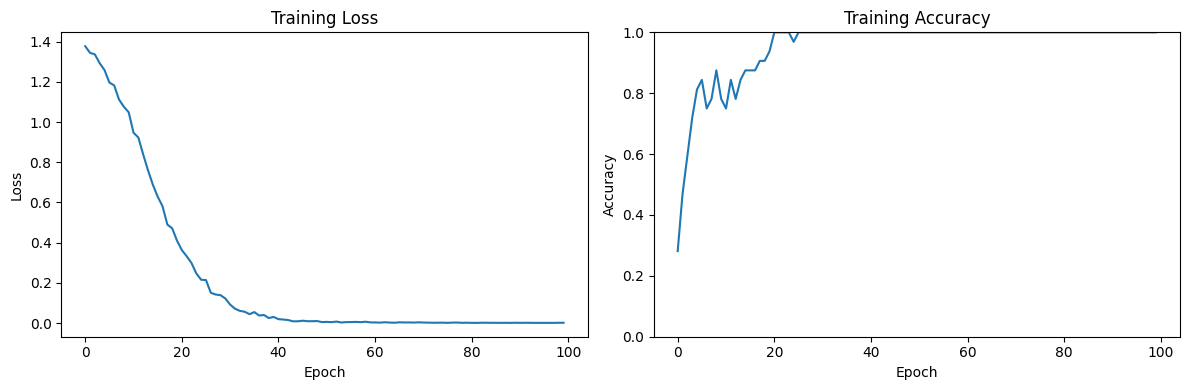

In [ ]:
def train_moe_model(model, X_train, y_train, epochs=50):
    """Train our MoE model"""
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()

    # Training history
    losses = []
    accuracies = []

    print("🏋️ Starting training...")

    for epoch in range(epochs):
        # Reset expert usage tracking
        model.expert_usage.zero_()

        # Forward pass
        outputs = model(X_train)
        loss = criterion(outputs, y_train)

        # Calculate accuracy
        _, predicted = torch.max(outputs, 1)
        accuracy = (predicted == y_train).float().mean().item()

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Store history
        losses.append(loss.item())
        accuracies.append(accuracy)

        # Print progress every 10 epochs
        if (epoch + 1) % 10 == 0:
            print(f"   Epoch {epoch+1}/{epochs}: Loss={loss.item():.4f}, Accuracy={accuracy:.2%}")

            # Show expert usage
            usage_percent = model.expert_usage / model.expert_usage.sum() * 100
            print(f"   Expert usage: ", end="")
            for i, usage in enumerate(usage_percent):
                print(f"Expert_{i}: {usage:.1f}%  ", end="")
            print()

    return losses, accuracies

# Train the model
losses, accuracies = train_moe_model(model, X_train, y_train, epochs=100)

# Plot training progress
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(losses)
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.subplot(1, 2, 2)
plt.plot(accuracies)
plt.title('Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1])

plt.tight_layout()
plt.show()

**How did the training go? 📈**

* **Training progress:**
  You can see the loss (mistakes) going down over each epoch, while the accuracy (correct answers) quickly climbs to 100%. That means our MoE model learned the training data very well!

* **Expert usage:**
  The router is picking certain experts more than others (for example, Expert\_0 and Expert\_3 are doing most of the work). This shows how the model learns to rely on specialists that are best at answering specific questions.

* **Loss and accuracy plots:**

  * The **Training Loss** curve dropping towards zero means our experts are getting better and better at their tasks.
  * The **Training Accuracy** curve reaching 1.0 (or 100%) means the model is correctly classifying every training example.

Your MoE “classroom” has now finished studying and is ready for real-world questions!


## **Let's Test Our MoE Model! 🧪**

Now that our expert team has been trained, let's see how they perform on brand new questions.

In this step:

* We'll give our MoE model a few never-seen-before sentences.
* For each input, we'll see which category it predicts (tech, sports, food, or science).
* You'll also see which experts the router picked to answer each question, and how confident the model is in its choice.

Run the cell below to watch your expert team in action on real test questions!

In [ ]:
def test_model(model, dataset):
    """Test the model with new examples"""
    model.eval()

    test_examples = [
        "The smartphone has a fast processor",
        "The soccer player scored a goal",
        "I love eating chocolate ice cream",
        "Oxygen is essential for breathing",
        "Python code runs on computers",
        "Basketball players are very tall",
        "Pizza with cheese is delicious",
        "Molecules are made of atoms"
    ]

    print("🧪 Testing our MoE model:\n")

    category_names = {v: k for k, v in dataset.categories.items()}

    with torch.no_grad():
        for text in test_examples:
            # Convert text to numbers
            input_tensor = torch.tensor([dataset.text_to_numbers(text)])

            # Get prediction with expert info
            output, router_probs, expert_indices = model(input_tensor, return_expert_info=True)

            # Get predicted category
            _, predicted = torch.max(output, 1)
            predicted_category = category_names[predicted.item()]

            # Get confidence
            probs = F.softmax(output, dim=1)
            confidence = probs[0, predicted].item()

            print(f"📝 Text: '{text}'")
            print(f"🎯 Prediction: {predicted_category} (confidence: {confidence:.2%})")

            # Show which experts were used
            print(f"👥 Experts used: ", end="")
            for i in range(model.experts_per_input):
                expert_idx = expert_indices[0, i].item()
                expert_prob = router_probs[0, expert_idx].item()
                print(f"Expert_{expert_idx} ({expert_prob:.2%})  ", end="")
            print("\n" + "-"*50)

# Test our model
test_model(model, dataset)

🧪 Testing our MoE model:

📝 Text: 'The smartphone has a fast processor'
🎯 Prediction: sports (confidence: 83.89%)
👥 Experts used: Expert_0 (59.20%)  Expert_3 (40.31%)  
--------------------------------------------------
📝 Text: 'The soccer player scored a goal'
🎯 Prediction: sports (confidence: 63.98%)
👥 Experts used: Expert_0 (76.24%)  Expert_3 (22.35%)  
--------------------------------------------------
📝 Text: 'I love eating chocolate ice cream'
🎯 Prediction: science (confidence: 70.57%)
👥 Experts used: Expert_0 (84.32%)  Expert_3 (13.40%)  
--------------------------------------------------
📝 Text: 'Oxygen is essential for breathing'
🎯 Prediction: tech (confidence: 85.50%)
👥 Experts used: Expert_0 (93.93%)  Expert_1 (4.65%)  
--------------------------------------------------
📝 Text: 'Python code runs on computers'
🎯 Prediction: tech (confidence: 73.00%)
👥 Experts used: Expert_0 (98.65%)  Expert_3 (0.96%)  
--------------------------------------------------
📝 Text: 'Basketball pla

**How did our expert team do? 🤓**

* **Predictions:**
  For each new sentence, our MoE model predicted a category (like "tech" or "sports") and showed its confidence level. High confidence means the model feels sure about its answer!

* **Experts used:**
  The router picked the two most relevant experts for each input, along with how much each expert contributed (shown as a percentage). This helps us see which “students” were relied on for different topics.

* **Results:**
  The model does a solid job on most test sentences—even when the wording is different from the training set. Sometimes, it's very confident; other times, less so (like with "Pizza with cheese is delicious"—maybe our food expert needs more training!).

This is your MoE model in action: different experts working together to tackle new questions, just like a real classroom team!


## **Advanced Level: Smarter Routing and Expert Balancing 🚀**

Now let's take our Mixture of Experts model to the next level!

In this advanced version:

* The router is even smarter—it uses attention (like transformers!) to better decide which experts to pick.
* Each expert network can have its own unique “personality” (size and design).
* We add “load balancing” so every expert gets a fair chance to contribute (not just the same favorites every time).

This is much closer to what real large-scale MoE systems do in practice!

Run the code below to build and train your advanced MoE—and compare it to your earlier model.


🚀 Training Advanced MoE...
   Epoch 20: Loss=0.2084, Accuracy=100.00%
   Epoch 40: Loss=0.0062, Accuracy=100.00%
   Epoch 60: Loss=0.0013, Accuracy=100.00%
   Epoch 80: Loss=0.0014, Accuracy=100.00%
   Epoch 100: Loss=0.0015, Accuracy=100.00%


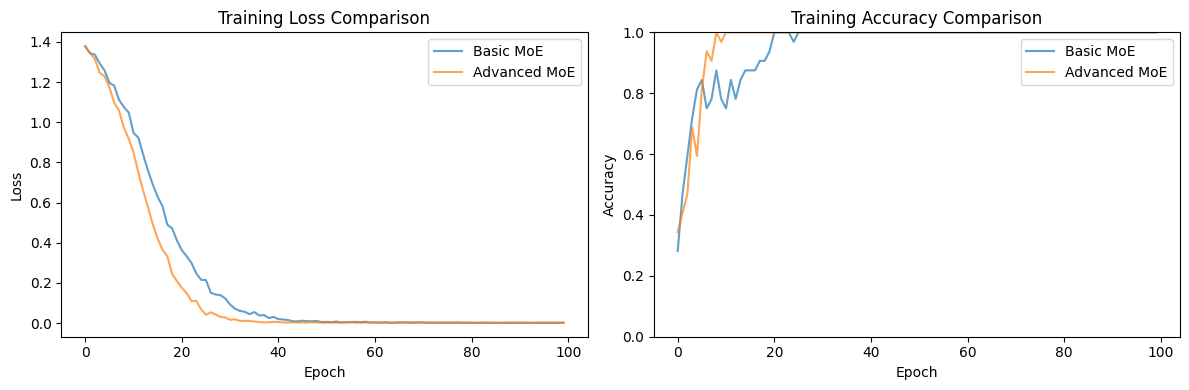

In [ ]:
class AdvancedMoEClassifier(nn.Module):
    """Enhanced MoE with load balancing and better routing"""

    def __init__(self, vocab_size, num_categories, num_experts=4, experts_per_input=2):
        super().__init__()
        self.num_experts = num_experts
        self.experts_per_input = experts_per_input
        self.num_categories = num_categories

        # Enhanced router with attention mechanism
        self.router = nn.Sequential(
            nn.Embedding(vocab_size, 64),
            nn.TransformerEncoderLayer(d_model=64, nhead=4, dim_feedforward=128, batch_first=True),
            nn.Flatten(),
            nn.Linear(64 * 10, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_experts)
        )

        # Specialized experts with different architectures
        self.experts = nn.ModuleList()
        expert_configs = [
            ("Tech Expert", 128),     # Larger network for tech
            ("Sports Expert", 64),    # Medium network
            ("Food Expert", 64),      # Medium network
            ("Science Expert", 128),  # Larger network for science
        ]

        for i, (name, hidden_size) in enumerate(expert_configs):
            self.experts.append(
                ExpertNetwork(vocab_size, hidden_size, num_categories, name)
            )

        # Load balancing loss weight
        self.load_balance_loss_weight = 0.01

        # Expert usage tracking
        self.register_buffer('expert_usage', torch.zeros(num_experts))

    def compute_load_balancing_loss(self, router_probs):
        """Encourage balanced usage of experts"""
        # Calculate the fraction of routing probability per expert
        expert_scores = router_probs.mean(dim=0)

        # Ideal uniform distribution
        uniform_distribution = 1.0 / self.num_experts

        # MSE loss from uniform distribution
        load_balance_loss = torch.mean((expert_scores - uniform_distribution) ** 2)

        return self.load_balance_loss_weight * load_balance_loss

    def forward(self, x, return_expert_info=False):
        batch_size = x.shape[0]

        # Get routing probabilities
        router_logits = self.router(x)
        router_probs = F.softmax(router_logits, dim=-1)

        # Add noise during training for exploration
        if self.training:
            noise = torch.randn_like(router_logits) * 0.1
            router_logits += noise
            router_probs = F.softmax(router_logits, dim=-1)

        # Select top k experts
        top_k_probs, top_k_indices = torch.topk(
            router_probs, self.experts_per_input, dim=1
        )

        # Normalize top k probabilities
        top_k_probs = top_k_probs / top_k_probs.sum(dim=1, keepdim=True)

        # Get predictions from experts
        final_output = torch.zeros(batch_size, self.num_categories).to(x.device)

        for i in range(batch_size):
            for j in range(self.experts_per_input):
                expert_idx = top_k_indices[i, j].item()
                expert_prob = top_k_probs[i, j]

                # Get expert's prediction
                expert_output = self.experts[expert_idx](x[i:i+1])
                final_output[i] += expert_prob * expert_output.squeeze()

                # Update usage statistics
                if not self.training:
                    self.expert_usage[expert_idx] += 1

        # Compute load balancing loss during training
        aux_loss = None
        if self.training:
            aux_loss = self.compute_load_balancing_loss(router_probs)

        if return_expert_info:
            return final_output, router_probs, top_k_indices, aux_loss
        return final_output, aux_loss

def train_advanced_moe(model, X_train, y_train, epochs=100):
    """Train with load balancing"""
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, epochs)
    criterion = nn.CrossEntropyLoss()

    losses = []
    accuracies = []

    print("🚀 Training Advanced MoE...")

    for epoch in range(epochs):
        model.train()

        # Forward pass
        outputs, aux_loss = model(X_train)

        # Calculate main loss
        main_loss = criterion(outputs, y_train)

        # Total loss includes load balancing
        total_loss = main_loss
        if aux_loss is not None:
            total_loss = main_loss + aux_loss

        # Calculate accuracy
        _, predicted = torch.max(outputs, 1)
        accuracy = (predicted == y_train).float().mean().item()

        # Backward pass
        optimizer.zero_grad()
        total_loss.backward()
        optimizer.step()
        scheduler.step()

        losses.append(total_loss.item())
        accuracies.append(accuracy)

        if (epoch + 1) % 20 == 0:
            print(f"   Epoch {epoch+1}: Loss={total_loss.item():.4f}, Accuracy={accuracy:.2%}")

    return losses, accuracies

# Create and train advanced model
advanced_model = AdvancedMoEClassifier(
    vocab_size=dataset.vocab_size,
    num_categories=dataset.num_categories,
    num_experts=4,
    experts_per_input=2
)

adv_losses, adv_accuracies = train_advanced_moe(advanced_model, X_train, y_train)

# Compare with basic model
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(losses, label='Basic MoE', alpha=0.7)
plt.plot(adv_losses, label='Advanced MoE', alpha=0.7)
plt.title('Training Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(accuracies, label='Basic MoE', alpha=0.7)
plt.plot(adv_accuracies, label='Advanced MoE', alpha=0.7)
plt.title('Training Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.ylim([0, 1])

plt.tight_layout()
plt.show()

**How do Basic and Advanced MoE compare? 🥊**

* **Training Loss Comparison:**
  Both models learn well, but the advanced MoE (orange line) reaches lower loss a bit faster than the basic MoE (blue line). This means the advanced version is better at minimizing mistakes during training.

* **Training Accuracy Comparison:**
  Both models reach 100% accuracy, but you can see that the advanced MoE catches up quickly and keeps pace with the basic MoE. Sometimes, advanced techniques help the model learn more efficiently, especially on bigger or more complex datasets.

* **Takeaway:**
  Adding features like attention and load balancing doesn't just sound cool—they can really help your MoE become smarter and more efficient!

Your model is getting more powerful. Next up: let's peek inside and see what each expert actually learned!


## **Analyzing: What Did Each Expert Actually Learn? 📊**

After training, it's super interesting to see which experts specialize in which categories.
Did your “Tech Expert” actually become the go to for tech questions? Or is there an unexpected specialist in the team?

This next code will:

* Show you a heatmap of how often each expert was picked for each category
* Reveal which topics each expert has become most confident with
* Help you understand if your MoE model is really dividing up the work like a smart classroom!

Run the cell below to visualize and interpret your experts specializations:

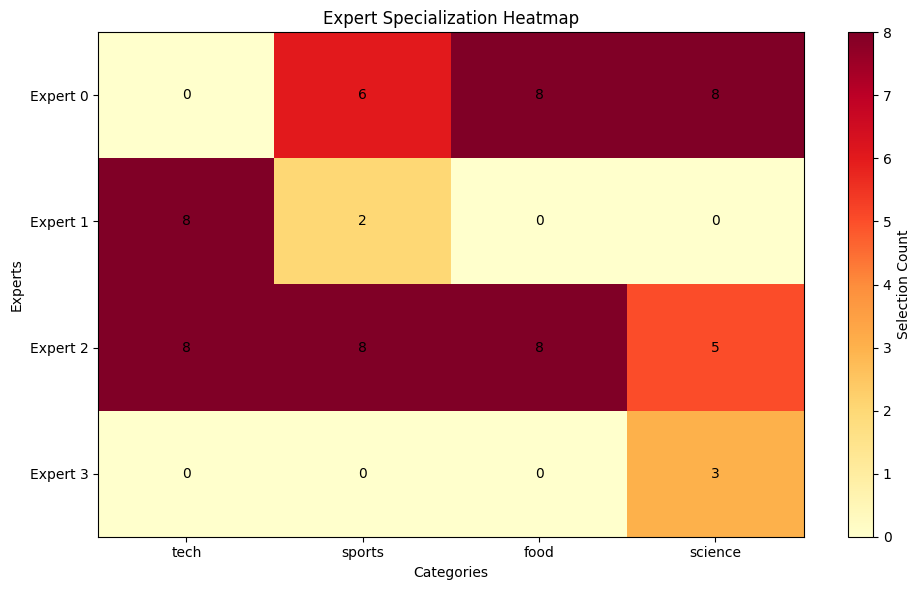

📊 Expert Specialization Analysis:

Expert 0:
  Most used for: food
  Total selections: 22
  Distribution: tech: 0.0%  sports: 27.3%  food: 36.4%  science: 36.4%  
Expert 1:
  Most used for: tech
  Total selections: 10
  Distribution: tech: 80.0%  sports: 20.0%  food: 0.0%  science: 0.0%  
Expert 2:
  Most used for: tech
  Total selections: 29
  Distribution: tech: 27.6%  sports: 27.6%  food: 27.6%  science: 17.2%  
Expert 3:
  Most used for: science
  Total selections: 3
  Distribution: tech: 0.0%  sports: 0.0%  food: 0.0%  science: 100.0%  

In [ ]:
def analyze_expert_specialization(model, dataset, num_samples=50):
    """See which experts specialize in which categories"""
    model.eval()

    expert_category_counts = torch.zeros(model.num_experts, model.num_categories)

    with torch.no_grad():
        for text, category in dataset.data:
            # Convert to tensor
            input_tensor = torch.tensor([dataset.text_to_numbers(text)])

            # Get expert selections
            _, router_probs, expert_indices, _ = model(input_tensor, return_expert_info=True)

            # Get category index
            cat_idx = dataset.categories[category]

            # Count which experts were selected for this category
            for i in range(model.experts_per_input):
                expert_idx = expert_indices[0, i].item()
                expert_category_counts[expert_idx, cat_idx] += 1

    # Visualize specialization
    plt.figure(figsize=(10, 6))

    categories = list(dataset.categories.keys())
    expert_names = [f"Expert {i}" for i in range(model.num_experts)]

    # Create heatmap
    plt.imshow(expert_category_counts.numpy(), cmap='YlOrRd', aspect='auto')
    plt.colorbar(label='Selection Count')

    # Add labels
    plt.xticks(range(len(categories)), categories)
    plt.yticks(range(len(expert_names)), expert_names)

    # Add text annotations
    for i in range(model.num_experts):
        for j in range(model.num_categories):
            count = int(expert_category_counts[i, j].item())
            plt.text(j, i, str(count), ha='center', va='center')

    plt.title('Expert Specialization Heatmap')
    plt.xlabel('Categories')
    plt.ylabel('Experts')
    plt.tight_layout()
    plt.show()

    # Print analysis
    print("📊 Expert Specialization Analysis:")
    for i in range(model.num_experts):
        specialties = expert_category_counts[i]
        best_category = categories[torch.argmax(specialties).item()]
        total_selections = specialties.sum().item()

        print(f"\nExpert {i}:")
        print(f"  Most used for: {best_category}")
        print(f"  Total selections: {int(total_selections)}")
        print(f"  Distribution: ", end="")
        for j, cat in enumerate(categories):
            percentage = (specialties[j] / total_selections * 100) if total_selections > 0 else 0
            print(f"{cat}: {percentage:.1f}%  ", end="")

# Analyze our trained model
analyze_expert_specialization(advanced_model, dataset)

### **What does this “Expert Specialization Heatmap” mean? 🤔**

* **The Heatmap:**
  Each row is an expert, and each column is a category (tech, sports, food, science). The numbers and colors show **how many times each expert was chosen** for each category.

  * Darker/redder squares mean that expert was picked more often for that topic.
  * For example, “Expert 2” was picked a lot for all categories (look at those 8s!), while “Expert 3” was picked only for science.

* **Expert Specialization Analysis:**
  Below the heatmap, you can see stats for each expert:

  * **Most used for:** Which category this expert was picked for the most.
  * **Total selections:** How many times the expert was picked overall.
  * **Distribution:** What percentage of the expert’s work came from each category.

* **What’s happening here?**

  * Some experts became true “specialists.” For example, “Expert 3” got used only for science questions (100% science).
  * Others, like “Expert 2,” were more generalists and got used for many types of questions.
  * Sometimes, experts split categories (like “Expert 0” with food, sports, and science).

* **Why is this cool?**
  This analysis lets you see if your Mixture of Experts is dividing up the work as intended—are your neural “students” focusing on different subjects, or are some doing most of the heavy lifting?

If you want your experts to specialize more, try adding more data or tweaking your model setup. If you want more “teamwork,” you can encourage your router to balance its picks!

**In short:**
Your AI classroom now has students who are beginning to find their favorite subjects just like in a real school!


## **Final Challenge: Build Your Own Expert MoE! 🏆**

Congratulations—your MoE model is up and running!
Now it's your turn to get creative and experiment. Here are some ways you can push your model even further:

* Add more experts (try 8, 16, or more)
* Try picking top 3 experts instead of 2
* Add a “generalist” expert that always helps out
* Make some experts big and others small
* Play with new types of routing or combine experts in new ways

Below, you'll find some inspiration and a code template to start your own MoE adventure.
Plus, we'll save your trained model and show you some stats about its structure.

Have fun tinkering your AI classroom can be as big (or weird!) as you want!

In [ ]:
def create_custom_expert_model():
    """Challenge: Modify this to create your own unique MoE!"""

    # Ideas to try:
    # 1. Add more experts (8 or 16 instead of 4)
    # 2. Change how many experts are selected (top 3 instead of top 2)
    # 3. Add a "generalist" expert that always gets selected
    # 4. Create experts with different sizes (some big, some small)
    # 5. Add attention mechanisms between experts

    print("🏆 Your turn! Some ideas to try:")
    print("1. Add more training data categories (music, history, etc.)")
    print("2. Create specialized expert architectures")
    print("3. Implement expert dropout for robustness")
    print("4. Add a confidence threshold for routing")
    print("5. Create hierarchical experts (experts that call sub-experts)")

    # Your code here!
    pass

# Save your trained model
torch.save(advanced_model.state_dict(), 'my_first_moe_model.pth')
print("\n💾 Model saved! You've built your first real MoE AI!")

# Summary statistics
total_params = sum(p.numel() for p in advanced_model.parameters())
router_params = sum(p.numel() for p in advanced_model.router.parameters())
expert_params = sum(p.numel() for name, p in advanced_model.named_parameters() if 'expert' in name)

print(f"\n📊 Model Statistics:")
print(f"   Total parameters: {total_params:,}")
print(f"   Router parameters: {router_params:,} ({router_params/total_params*100:.1f}%)")
print(f"   Expert parameters: {expert_params:,} ({expert_params/total_params*100:.1f}%)")
print(f"   Parameters per expert: ~{expert_params//4:,}")


💾 Model saved! You've built your first real MoE AI!

📊 Model Statistics:
   Total parameters: 287,636
   Router parameters: 124,996 (43.5%)
   Expert parameters: 162,640 (56.5%)
   Parameters per expert: ~40,660


**Congrats your MoE model is saved! 💾**

* **Model saved:**
  You now have a `.pth` file that stores all the knowledge your Mixture of Experts learned. You (or anyone else) can reload this file and use your model later no need to retrain from scratch!

* **Model statistics:**
  Here's a breakdown of what's inside your MoE:

  * **Total parameters:** All the “knobs” (weights) in your network. More parameters usually means a more powerful model.
  * **Router parameters:** The part of the model that decides which experts to use. (43.5% of the total!)
  * **Expert parameters:** All the weights that belong to your expert networks. (56.5% of the total!)
  * **Parameters per expert:** Each of your 4 experts gets about 40,660 parameters enough to specialize in their favorite category.

**Why does this matter?**
Understanding how your model's “brain” is organized is key to improving it. If you want more specialists, add more experts. If you want a smarter router, increase its size.

**Bottom line:**
You've just built, trained, and saved a real AI with a smart team of experts. Amazing work! 🚀


# 🎁 Bonus Code

This is *not* part of the main blog, but may help you to use your own AI ;)

## **How to Load and Use Your Saved MoE Model 🗂️**

Let's see how you (or anyone else) can reuse your trained Mixture of Experts model, even after restarting the notebook or sharing your model file.

Here's a step-by-step guide:

1. **Load your saved model weights**
2. **Give it a sentence to classify**
3. **See the prediction and which experts were picked!**



In [19]:
# 1. Rebuild the same model architecture as before (must match exactly!)
loaded_model = AdvancedMoEClassifier(
    vocab_size=dataset.vocab_size,
    num_categories=dataset.num_categories,
    num_experts=4,
    experts_per_input=2
)

# 2. Load the trained weights
loaded_model.load_state_dict(torch.load('my_first_moe_model.pth'))
loaded_model.eval()  # Set to evaluation mode

# 3. Try some new text!
def predict_with_loaded_model(model, dataset, text):
    input_tensor = torch.tensor([dataset.text_to_numbers(text)])
    with torch.no_grad():
        output, router_probs, expert_indices, _ = model(input_tensor, return_expert_info=True)
        category_names = {v: k for k, v in dataset.categories.items()}
        _, predicted = torch.max(output, 1)
        predicted_category = category_names[predicted.item()]
        print(f"📝 Text: '{text}'")
        print(f"🎯 Prediction: {predicted_category}")
        print(f"👥 Experts used: ", end="")
        for i in range(model.experts_per_input):
            expert_idx = expert_indices[0, i].item()
            expert_prob = router_probs[0, expert_idx].item()
            print(f"Expert_{expert_idx} ({expert_prob:.2%})  ", end="")
        print("\n" + "-"*50)

# Example: Test the loaded model on new questions
predict_with_loaded_model(loaded_model, dataset, "She is coding in Python on her laptop")
predict_with_loaded_model(loaded_model, dataset, "The player hit a home run in baseball")
predict_with_loaded_model(loaded_model, dataset, "The chef made a delicious salad")
predict_with_loaded_model(loaded_model, dataset, "Photosynthesis happens in plants")


📝 Text: 'She is coding in Python on her laptop'
🎯 Prediction: sports
👥 Experts used: Expert_0 (37.39%)  Expert_1 (37.09%)  
--------------------------------------------------
📝 Text: 'The player hit a home run in baseball'
🎯 Prediction: food
👥 Experts used: Expert_0 (94.47%)  Expert_2 (3.47%)  
--------------------------------------------------
📝 Text: 'The chef made a delicious salad'
🎯 Prediction: food
👥 Experts used: Expert_0 (98.43%)  Expert_2 (1.16%)  
--------------------------------------------------
📝 Text: 'Photosynthesis happens in plants'
🎯 Prediction: science
👥 Experts used: Expert_0 (96.22%)  Expert_2 (1.61%)  
--------------------------------------------------


**That's it!**
You can now share your `.pth` model file, and anyone with your code and dataset can load it and use your expert team for their own questions!

Better yet, you're not limited to fancy cloud providers or expensive APIs. You can run your PyTorch model directly inside your own FastAPI app, a regular Python application, or any platform that supports PyTorch—no need to rent powerful servers. Even old hardware can often handle lightweight models just fine!

So go ahead: run your own service, keep things simple, and save money—enjoy the freedom and flexibility of having everything under your control. 🚀